In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

# Загрузка и визуализация датасета

In [3]:
car_ins = pd.read_csv('../data/raw/car_insurance.csv')
print(car_ins[:10])

       ID    AGE  GENDER DRIVING_EXPERIENCE    EDUCATION         INCOME  \
0  569520    65+  female               0-9y  high school    upper class   
1  750365  16-25    male               0-9y         none        poverty   
2  199901  16-25  female               0-9y  high school  working class   
3  478866  16-25    male               0-9y   university  working class   
4  731664  26-39    male             10-19y         none  working class   
5  877557  40-64  female             20-29y  high school    upper class   
6  930134    65+    male               30y+  high school    upper class   
7  461006  26-39  female               0-9y   university  working class   
8   68366  40-64  female             20-29y   university  working class   
9  445911  40-64  female               0-9y  high school    upper class   

   CREDIT_SCORE  VEHICLE_OWNERSHIP  MARRIED  CHILDREN  POSTAL_CODE  \
0      0.629027                  1        0         1        10238   
1      0.357757                  0

ID - бессмысленный для задачи столбец

In [4]:
car_ins.drop(['ID'], axis=1, inplace=True)

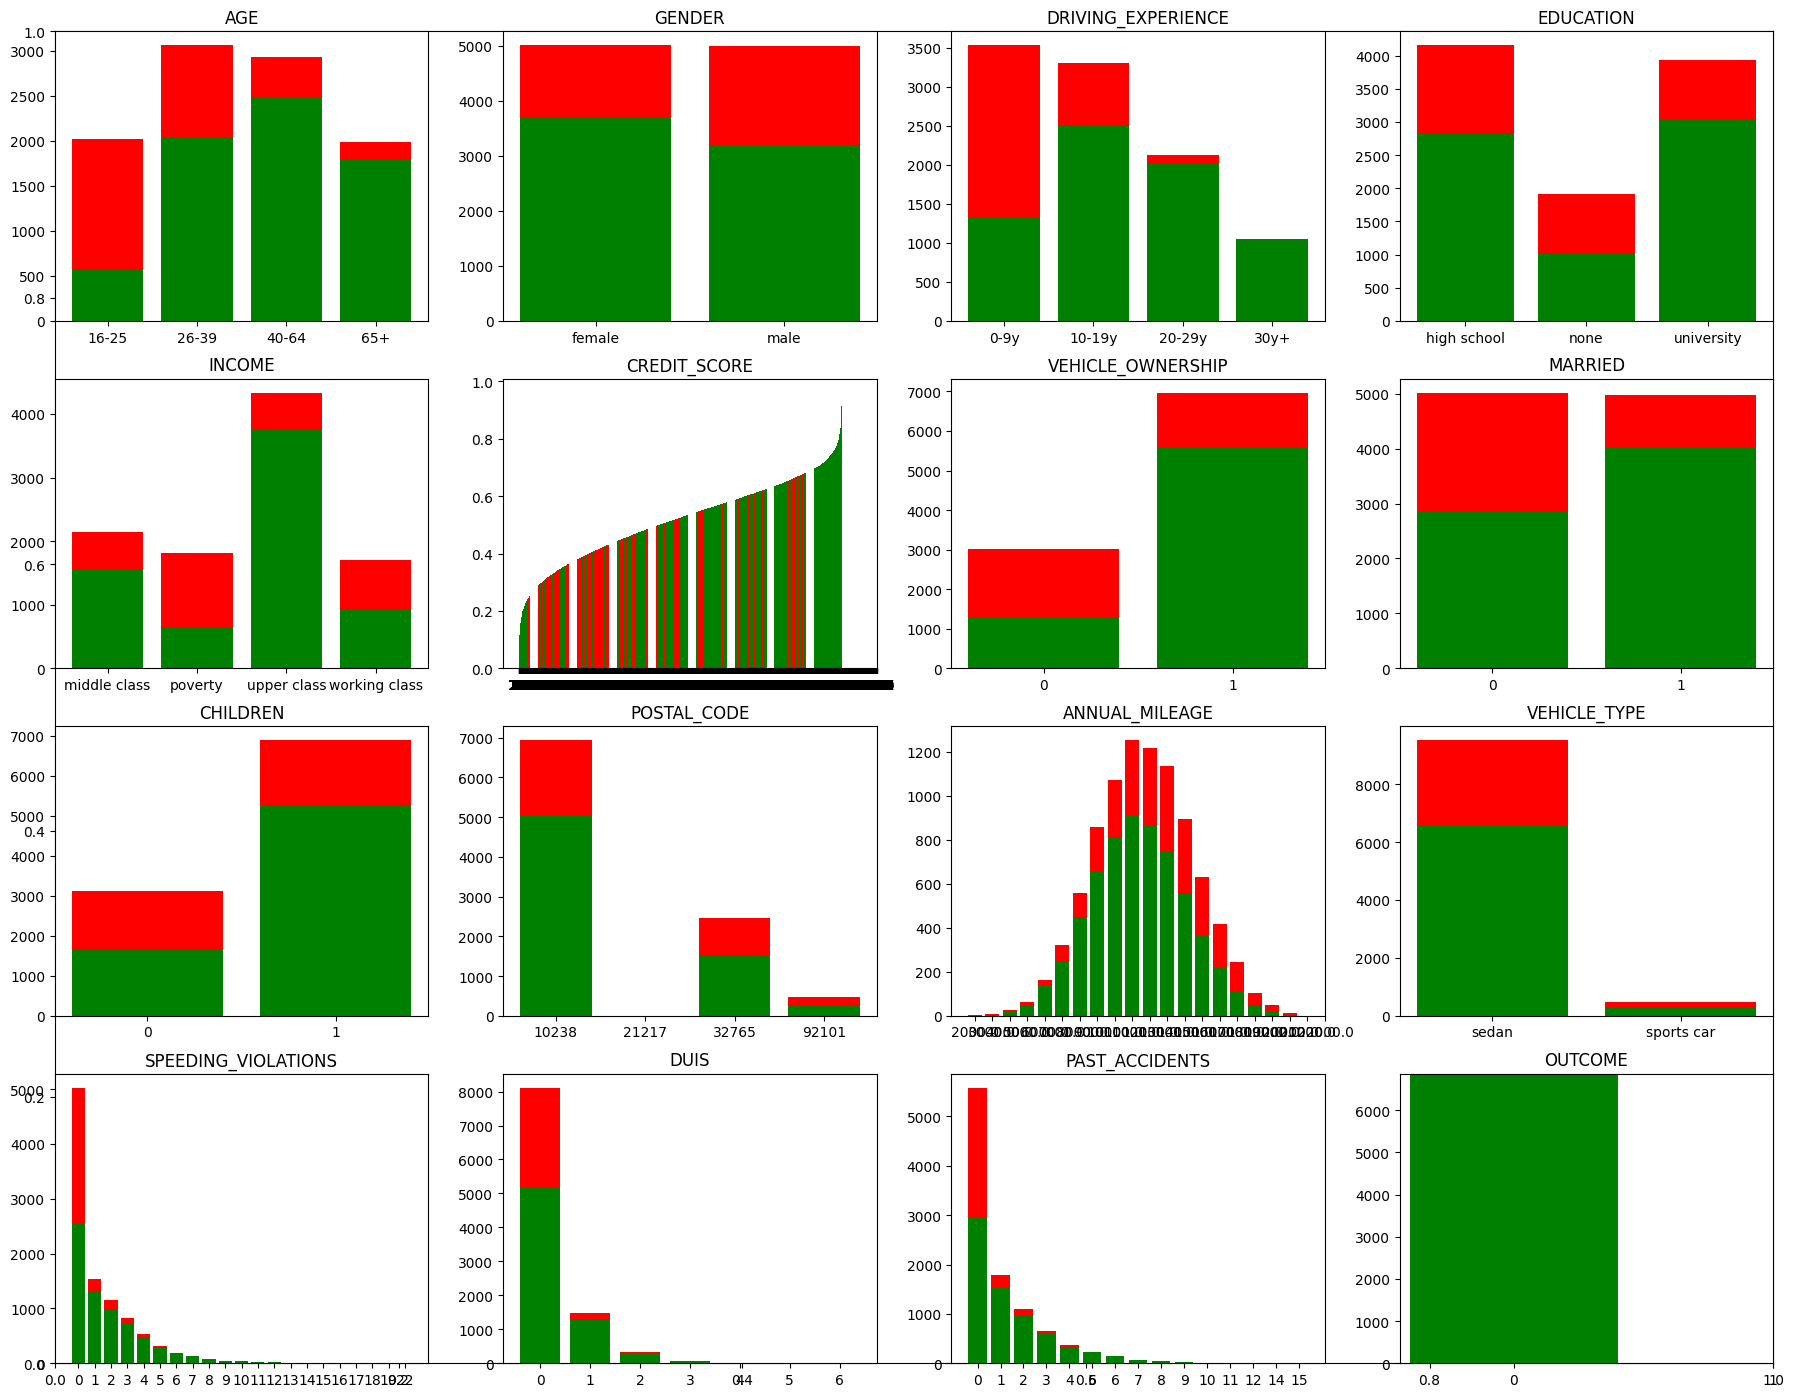

In [24]:
cols = car_ins.columns
frecs = []
for x in cols:
    df1 = car_ins[car_ins['OUTCOME']==0][x].value_counts()
    df2 = car_ins[car_ins['OUTCOME']==1][x].value_counts()
    df = pd.merge(df1, df2, 'outer', on = x)
    df.columns = ['safe', 'incident']
    frecs.append(df)

fig, ax = plt.subplots(figsize=(19,15))
fig.tight_layout(pad=5)

def plot_stacked(data, subplot, bot1):
    labels = data.index.tolist()
    safe = np.array(data['safe'])
    incident = np.array(data['incident'])
    x = np.arange(len(data))
    plt.subplot(4,4,subplot)
    plt.bar(x, safe, label='safe', color='green')
    plt.bar(x, incident, bottom=bot1, label='incident', color='red')
    plt.xticks(x, labels)
    plt.title(cols[subplot-1])
    return None

for n in range(16):
    match n:
        case 5:
            df = car_ins.sort_values('CREDIT_SCORE')[['CREDIT_SCORE', 'OUTCOME']].reset_index(drop=True)
            df1 = df[df['OUTCOME']==0]
            df2 = df[df['OUTCOME']==1]
            label_1 = df1.index.to_list()
            label_2 = df2.index.to_list()
            x = np.arange(len(df))
            plt.subplot(4,4,6)
            plt.bar(label_1, np.array(df1['CREDIT_SCORE']), color='green')
            plt.bar(label_2, np.array(df2['CREDIT_SCORE']), color='red')
            plt.xticks(x, label_1+label_2)
            plt.title(cols[n])
        case _:
            plot_stacked(frecs[n], n+1, bot1=np.array(frecs[n]['safe']))

plt.show()

Не все графики хорошо читаются или правильно формируются, но уже ясно, что POSTAL_CODE не даёт информации о выплате.

In [25]:
car_ins.drop(['POSTAL_CODE'], axis=1, inplace=True)

# Поиск и заполнение пропусков

In [26]:
print(car_ins.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  10000 non-null  str    
 1   GENDER               10000 non-null  str    
 2   DRIVING_EXPERIENCE   10000 non-null  str    
 3   EDUCATION            10000 non-null  str    
 4   INCOME               10000 non-null  str    
 5   CREDIT_SCORE         9018 non-null   float64
 6   VEHICLE_OWNERSHIP    10000 non-null  int64  
 7   MARRIED              10000 non-null  int64  
 8   CHILDREN             10000 non-null  int64  
 9   ANNUAL_MILEAGE       9043 non-null   float64
 10  VEHICLE_TYPE         10000 non-null  str    
 11  SPEEDING_VIOLATIONS  10000 non-null  int64  
 12  DUIS                 10000 non-null  int64  
 13  PAST_ACCIDENTS       10000 non-null  int64  
 14  OUTCOME              10000 non-null  int64  
dtypes: float64(2), int64(7), str(6)
memory usage: 1.

In [27]:
exp_thing = car_ins[['DRIVING_EXPERIENCE', 'ANNUAL_MILEAGE']].groupby('DRIVING_EXPERIENCE', dropna=False).apply(lambda x: x.isna().sum())
exp_thing[['%_MISSED']] = exp_thing[['ANNUAL_MILEAGE']]/car_ins[['DRIVING_EXPERIENCE', 'ANNUAL_MILEAGE']].groupby('DRIVING_EXPERIENCE', dropna=False).count() * 100
exp_thing[['MEAN_MILES']] = car_ins[['DRIVING_EXPERIENCE', 'ANNUAL_MILEAGE']].groupby('DRIVING_EXPERIENCE', dropna=False).mean()
print(exp_thing)

credit_thing = car_ins[['INCOME','CREDIT_SCORE']].groupby('INCOME').mean()
print(credit_thing)

                    ANNUAL_MILEAGE   %_MISSED    MEAN_MILES
DRIVING_EXPERIENCE                                         
0-9y                           363  11.461951  12249.131670
10-19y                         319  10.704698  11791.275168
20-29y                         177   9.114315  11144.181256
30y+                            98  10.272537  10694.968553
               CREDIT_SCORE
INCOME                     
middle class       0.523659
poverty            0.348331
upper class        0.613827
working class      0.431929


Как видно, в столбцах CREDIT_SCORE и ANNUAL_MILEAGE нет около 10% значений, что много. Кредитный рейтинг может быть восстановлен, как среднее значение для класса дохода, а в ежегодном пробеге пропуски достаточно стабильны, чтобы просто заполнить их средним значением. Информация о наличии пропуска будет сохранена в отдельных столбцах на всякий случай.

In [28]:
car_ins[['NULL_ANNUAL_MILEAGE']] = car_ins[['ANNUAL_MILEAGE']].isna().astype(int)
car_ins[['ANNUAL_MILEAGE']] = car_ins[['ANNUAL_MILEAGE']].fillna(car_ins[['ANNUAL_MILEAGE']].mean())

car_ins[['NULL_CREDIT_SCORE']] = car_ins[['CREDIT_SCORE']].isna().astype(int)
for x in car_ins['INCOME'].unique():
    car_ins[car_ins['INCOME']==x] = car_ins[car_ins['INCOME']==x].fillna(credit_thing.loc[x, 'CREDIT_SCORE'])

In [29]:
print(car_ins.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE                  10000 non-null  str    
 1   GENDER               10000 non-null  str    
 2   DRIVING_EXPERIENCE   10000 non-null  str    
 3   EDUCATION            10000 non-null  str    
 4   INCOME               10000 non-null  str    
 5   CREDIT_SCORE         10000 non-null  float64
 6   VEHICLE_OWNERSHIP    10000 non-null  int64  
 7   MARRIED              10000 non-null  int64  
 8   CHILDREN             10000 non-null  int64  
 9   ANNUAL_MILEAGE       10000 non-null  float64
 10  VEHICLE_TYPE         10000 non-null  str    
 11  SPEEDING_VIOLATIONS  10000 non-null  int64  
 12  DUIS                 10000 non-null  int64  
 13  PAST_ACCIDENTS       10000 non-null  int64  
 14  OUTCOME              10000 non-null  int64  
 15  NULL_ANNUAL_MILEAGE  10000 non-null  int64  
 16

# Кодирование не цифровых значений

Код нужен для вывода категорий.

In [30]:
print(car_ins['DRIVING_EXPERIENCE'].unique())

<StringArray>
['0-9y', '10-19y', '20-29y', '30y+']
Length: 4, dtype: str


| Не цифровой столбец | Уникальные значения | Тип кодирования  |
|--------------------|--------------------------------------------------------|----------------|
| AGE                | '16-25' '26-39' '40-64' '65+'                          | OrdinalEncoder |
| GENDER             | 'female' 'male'                                        | LabelEncoder   |
| DRIVING_EXPERIENCE | '0-9y' '10-19y' '20-29y' '30y+'                        | OrdinalEncoder |
| EDUCATION          | 'none' 'high school' 'university'                      | OrdinalEncoder |
| INCOME             | 'poverty' 'working class' 'middle class' 'upper class' | OrdinalEncoder |
| VEHICLE_TYPE       | 'sedan' 'sports car'                                   | OneHotEncoder  |

In [31]:
cop = car_ins.copy()
label_encoder = LabelEncoder()
cop['GENDER'] = label_encoder.fit_transform(cop['GENDER'])

onehot_encoder = OneHotEncoder()
cop[['SEDAN', 'SPORTS_CAR']] = onehot_encoder.fit_transform(cop[['VEHICLE_TYPE']]).toarray()
cop.drop(['VEHICLE_TYPE'], axis=1, inplace=True)

age_encoder = OrdinalEncoder(categories=[['16-25', '26-39', '40-64', '65+']])
exp_encoder = OrdinalEncoder(categories=[['0-9y', '10-19y', '20-29y', '30y+']])
edu_encoder = OrdinalEncoder(categories=[['none', 'high school', 'university']])
income_encoder = OrdinalEncoder(categories=[['poverty', 'working class', 'middle class', 'upper class']])
cop['AGE'] = age_encoder.fit_transform(cop[['AGE']])
cop['DRIVING_EXPERIENCE'] = exp_encoder.fit_transform(cop[['DRIVING_EXPERIENCE']])
cop['EDUCATION'] = edu_encoder.fit_transform(cop[['EDUCATION']])
cop['INCOME'] = income_encoder.fit_transform(cop[['INCOME']])

print(cop)

      AGE  GENDER  DRIVING_EXPERIENCE  EDUCATION  INCOME  CREDIT_SCORE  \
0     3.0       0                 0.0        1.0     3.0      0.629027   
1     0.0       1                 0.0        0.0     0.0      0.357757   
2     0.0       0                 0.0        1.0     1.0      0.493146   
3     0.0       1                 0.0        2.0     1.0      0.206013   
4     1.0       1                 1.0        0.0     1.0      0.388366   
...   ...     ...                 ...        ...     ...           ...   
9995  1.0       0                 1.0        2.0     3.0      0.582787   
9996  1.0       0                 1.0        0.0     2.0      0.522231   
9997  1.0       1                 0.0        1.0     2.0      0.470940   
9998  1.0       0                 1.0        1.0     0.0      0.364185   
9999  1.0       0                 0.0        0.0     1.0      0.435225   

      VEHICLE_OWNERSHIP  MARRIED  CHILDREN  ANNUAL_MILEAGE  \
0                     1        0         1    120

In [32]:
print(cop.columns)

Index(['AGE', 'GENDER', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME',
       'CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN',
       'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS',
       'OUTCOME', 'NULL_ANNUAL_MILEAGE', 'NULL_CREDIT_SCORE', 'SEDAN',
       'SPORTS_CAR'],
      dtype='str')


Ниже перетасовываем столбцы и переназываем датасет.

In [33]:
columns_order = ['AGE', 'GENDER', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME', 'CREDIT_SCORE', 'NULL_CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN', 'ANNUAL_MILEAGE', 'NULL_ANNUAL_MILEAGE', 'SEDAN', 'SPORTS_CAR', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS', 'OUTCOME']
car_ins_encoded = cop.reindex(columns=columns_order)

# Корреляции

Как видно ниже, случай не случился, информацию о пропуске храний не надо. Ещё видно, что тип машины почти не влияет.

<Axes: >

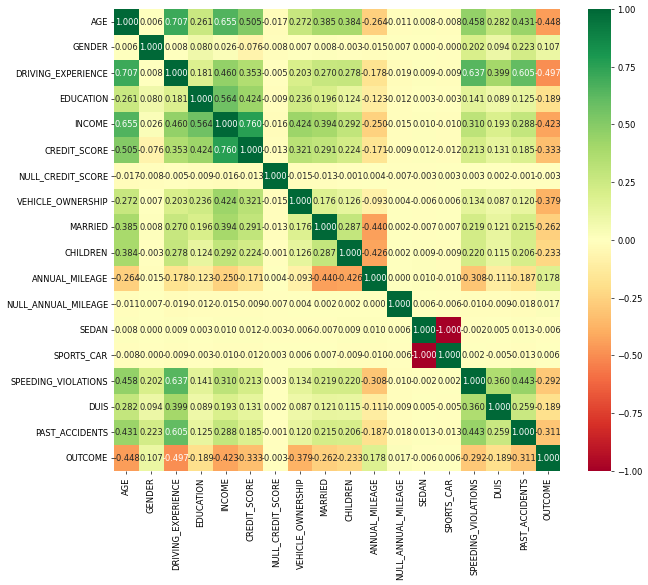

In [34]:
plt.figure(figsize=(12, 10), dpi=60)
df1 = car_ins_encoded.copy()
df1_n = df1.select_dtypes(['number'])
df1_corr = df1_n.corr()
sns.heatmap(df1_corr, xticklabels=df1_corr.columns, yticklabels=df1_corr.columns, annot=True, fmt='.3f', cmap='RdYlGn')

In [38]:
car_ins_encoded.drop(['NULL_CREDIT_SCORE', 'NULL_ANNUAL_MILEAGE', 'SEDAN', 'SPORTS_CAR'], axis=1, inplace=True)

# Выгрузка датасета

In [39]:
print(car_ins_encoded.columns)

Index(['AGE', 'GENDER', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME',
       'CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN',
       'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS',
       'OUTCOME'],
      dtype='str')


In [40]:
car_ins_encoded.to_csv('../data/processed/car_insurance.csv')